In [1]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# ------------------------------------------
# desabilita warnings
# ------------------------------------------
import warnings
warnings.filterwarnings('ignore')

In [3]:
# ------------------------------------------
# bibliotecas principais
# ------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [4]:
# ------------------------------------------
# DATABASE: DF-CONSOLIDADO
# ------------------------------------------
df = pd.read_csv("/content/drive/Shareddrives/grupo4-rappi-hour/bases-rappi/df-consolidado.csv")
print(f"Total de linhas: {df.shape[0]}")
df.info()

Total de linhas: 159576
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159576 entries, 0 to 159575
Data columns (total 50 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   Unnamed: 0                      159576 non-null  int64  
 1   ID                              159576 non-null  int64  
 2   GENERO                          159576 non-null  object 
 3   DATA_NASCIMENTO                 159576 non-null  float64
 4   CIDADE                          159576 non-null  object 
 5   IS_ACTIVE                       159576 non-null  object 
 6   TRANSPORTE                      159576 non-null  object 
 7   AUTO_ACEITE                     140510 non-null  object 
 8   COUNT_ORDERS_LAST_7D            159576 non-null  float64
 9   COUNT_ORDERS_LAST_30D           159576 non-null  float64
 10  COUNT_ORDERS_CANCELED_LAST_7D   159576 non-null  float64
 11  COUNT_ORDERS_CANCELED_LAST_30D  159576 non-null  float

In [5]:
# ------------------------------------------
# selecao das features numericas
# ------------------------------------------
df_model = df.select_dtypes(include=np.number)

In [6]:
# ------------------------------------------
# TARGET : coluna IS_ACTIVE
#
# TODO : tratamento de features !!!
# ------------------------------------------
df_model = pd.concat([df_model, df["IS_ACTIVE"]], axis=1)
df_model.replace({'IS_ACTIVE': False}, "False", inplace=True)
df_model.drop(labels="Unnamed: 0", axis=1, inplace = True)
df_model.dropna(axis=1, inplace=True)
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159576 entries, 0 to 159575
Data columns (total 13 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   ID                              159576 non-null  int64  
 1   DATA_NASCIMENTO                 159576 non-null  float64
 2   COUNT_ORDERS_LAST_7D            159576 non-null  float64
 3   COUNT_ORDERS_LAST_30D           159576 non-null  float64
 4   COUNT_ORDERS_CANCELED_LAST_7D   159576 non-null  float64
 5   COUNT_ORDERS_CANCELED_LAST_30D  159576 non-null  float64
 6   GORJETA                         159576 non-null  float64
 7   COUNT_ORDERS_RESTAURANTES       159576 non-null  float64
 8   COUNT_ORDERS_MERCADO            159576 non-null  float64
 9   COUNT_ORDERS_FARMACIA           159576 non-null  float64
 10  COUNT_ORDERS_EXPRESS            159576 non-null  float64
 11  COUNT_ORDERS_ANTOJO             159576 non-null  float64
 12  IS_ACTIVE       

In [7]:
# ------------------------------------------
# desbalanco consideravel no target
# TODO : enderecar isso em versoes futuras do modelo
# ------------------------------------------
df_model["IS_ACTIVE"].value_counts(normalize=True)

Quasi    0.633805
True     0.245939
False    0.120256
Name: IS_ACTIVE, dtype: float64

In [8]:
# ------------------------------------------
# SEPARACAO ENTRE TARGET E FEATURES - PASSO 1
# ------------------------------------------
X = df_model.drop(columns="IS_ACTIVE")
y = df_model["IS_ACTIVE"]

In [9]:
# ------------------------------------------
# SEPARACAO ENTRE TARGET E FEATURES - PASSO 2
# ------------------------------------------
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [10]:
# ------------------------------------------
# IMPORTANTE : notar que os percentuais da base de treino foram mantidos
# ------------------------------------------
y_train.value_counts(normalize=True)

Quasi    0.633801
True     0.245942
False    0.120257
Name: IS_ACTIVE, dtype: float64

In [11]:
# ------------------------------------------
# IMPORTANTE : notar que os percentuais da base de testes foram mantidos
# ------------------------------------------
y_test.value_counts(normalize=True)

Quasi    0.633820
True     0.245927
False    0.120253
Name: IS_ACTIVE, dtype: float64

In [12]:
# ------------------------------------------
# BASELINE MODEL : LOGIT
# ------------------------------------------
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression


Métricas de avaliação de treino:
[[    0 15344     8]
 [    0 79863  1048]
 [   11 18636 12750]]


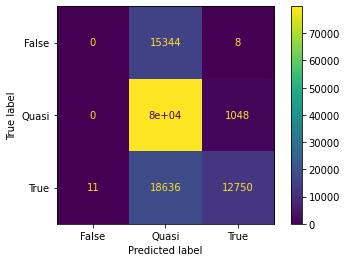

              precision    recall  f1-score   support

       False       0.00      0.00      0.00     15352
       Quasi       0.70      0.99      0.82     80911
        True       0.92      0.41      0.56     31397

    accuracy                           0.73    127660
   macro avg       0.54      0.46      0.46    127660
weighted avg       0.67      0.73      0.66    127660


Métricas de avaliação de teste:
[[    0  3837     1]
 [    1 19964   264]
 [    0  4781  3068]]


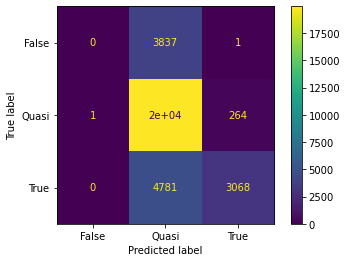

              precision    recall  f1-score   support

       False       0.00      0.00      0.00      3838
       Quasi       0.70      0.99      0.82     20229
        True       0.92      0.39      0.55      7849

    accuracy                           0.72     31916
   macro avg       0.54      0.46      0.46     31916
weighted avg       0.67      0.72      0.65     31916



In [13]:
# ============================================

lr = LogisticRegression().fit(X_train, y_train)

# ============================================

print("\nMétricas de avaliação de treino:")

y_pred_train = lr.predict(X_train)

print(confusion_matrix(y_train, y_pred_train))

ConfusionMatrixDisplay.from_predictions(y_train, y_pred_train)
plt.show()

print(classification_report(y_train, y_pred_train))

# ============================================

print("\nMétricas de avaliação de teste:")

y_pred_test = lr.predict(X_test)

print(confusion_matrix(y_test, y_pred_test))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test)
plt.show()

print(classification_report(y_test, y_pred_test))

In [14]:
# ------------------------------------------
# MODEL : DECISION TREE (PRIMEIRA TENTATIVA)
# ------------------------------------------ 
from sklearn.tree import DecisionTreeClassifier


Métricas de avaliação de treino:
[[15352     0     0]
 [    0 80911     0]
 [    0     0 31397]]


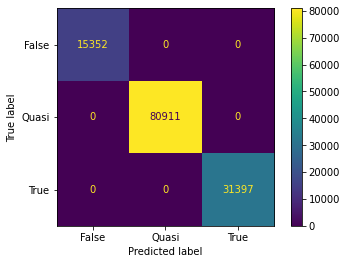

              precision    recall  f1-score   support

       False       1.00      1.00      1.00     15352
       Quasi       1.00      1.00      1.00     80911
        True       1.00      1.00      1.00     31397

    accuracy                           1.00    127660
   macro avg       1.00      1.00      1.00    127660
weighted avg       1.00      1.00      1.00    127660


Métricas de avaliação de teste:
[[ 3790    27    21]
 [   29 19400   800]
 [   19   867  6963]]


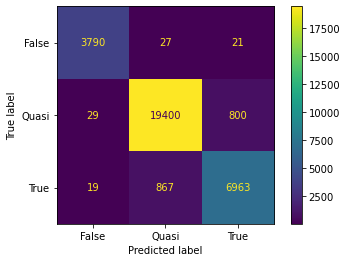

              precision    recall  f1-score   support

       False       0.99      0.99      0.99      3838
       Quasi       0.96      0.96      0.96     20229
        True       0.89      0.89      0.89      7849

    accuracy                           0.94     31916
   macro avg       0.95      0.94      0.95     31916
weighted avg       0.94      0.94      0.94     31916



In [15]:
# ============================================

dt = DecisionTreeClassifier().fit(X_train, y_train)

# ============================================

print("\nMétricas de avaliação de treino:")

y_pred_train = dt.predict(X_train)

print(confusion_matrix(y_train, y_pred_train))

ConfusionMatrixDisplay.from_predictions(y_train, y_pred_train)
plt.show()

print(classification_report(y_train, y_pred_train))

# ============================================

print("\nMétricas de avaliação de teste:")

y_pred_test = dt.predict(X_test)

print(confusion_matrix(y_test, y_pred_test))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test)
plt.show()

print(classification_report(y_test, y_pred_test))

In [16]:
# ------------------------------------------
# CONCLUSAO : modelo overfittado 
# arvore muito profunda == modelo muito complexo
# ------------------------------------------ 
print(dt.get_depth(), dt.get_n_leaves())

50 5900


In [17]:
# ------------------------------------------
# MODEL : DECISION TREE (SEGUNDA TENTATIVA)
#         usando Search Grid para otimizar a decisao de hiperparametros
# ------------------------------------------ 
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [18]:
# ============================================
# pipe com só uma etapa (modelagem), pq nao fizemos nada de preprocessamento

pipe = Pipeline([("dt", DecisionTreeClassifier(random_state=42))])

# ============================================

params_grid_dt = {"dt__criterion" : ["gini", "entropy"],
                  "dt__splitter" : ["best", "random"],
                  "dt__max_depth" : range(2, 11)} 

splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_dt = GridSearchCV(estimator=pipe,
                       param_grid=params_grid_dt,
                       scoring="f1_weighted",
                       cv=splitter,
                       verbose=10)

grid_dt.fit(X_train, y_train)

# ============================================

Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV 1/5; 1/36] START dt__criterion=gini, dt__max_depth=2, dt__splitter=best.....
[CV 1/5; 1/36] END dt__criterion=gini, dt__max_depth=2, dt__splitter=best;, score=0.885 total time=   0.5s
[CV 2/5; 1/36] START dt__criterion=gini, dt__max_depth=2, dt__splitter=best.....
[CV 2/5; 1/36] END dt__criterion=gini, dt__max_depth=2, dt__splitter=best;, score=0.888 total time=   0.5s
[CV 3/5; 1/36] START dt__criterion=gini, dt__max_depth=2, dt__splitter=best.....
[CV 3/5; 1/36] END dt__criterion=gini, dt__max_depth=2, dt__splitter=best;, score=0.887 total time=   0.5s
[CV 4/5; 1/36] START dt__criterion=gini, dt__max_depth=2, dt__splitter=best.....
[CV 4/5; 1/36] END dt__criterion=gini, dt__max_depth=2, dt__splitter=best;, score=0.886 total time=   0.5s
[CV 5/5; 1/36] START dt__criterion=gini, dt__max_depth=2, dt__splitter=best.....
[CV 5/5; 1/36] END dt__criterion=gini, dt__max_depth=2, dt__splitter=best;, score=0.886 total time=   0.5

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('dt',
                                        DecisionTreeClassifier(random_state=42))]),
             param_grid={'dt__criterion': ['gini', 'entropy'],
                         'dt__max_depth': range(2, 11),
                         'dt__splitter': ['best', 'random']},
             scoring='f1_weighted', verbose=10)

In [19]:
grid_dt.best_params_

{'dt__criterion': 'gini', 'dt__max_depth': 9, 'dt__splitter': 'best'}


Métricas de avaliação de treino:
[[15255    80    17]
 [   43 77421  3447]
 [   82  1018 30297]]


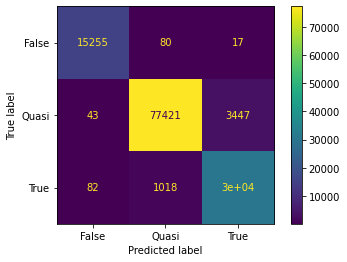

              precision    recall  f1-score   support

       False       0.99      0.99      0.99     15352
       Quasi       0.99      0.96      0.97     80911
        True       0.90      0.96      0.93     31397

    accuracy                           0.96    127660
   macro avg       0.96      0.97      0.96    127660
weighted avg       0.96      0.96      0.96    127660


Métricas de avaliação de teste:
[[ 3820    15     3]
 [    5 19338   886]
 [   19   291  7539]]


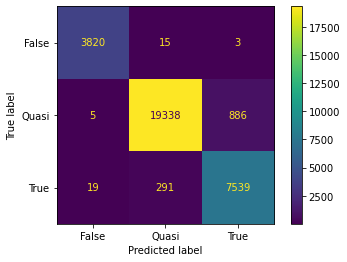

              precision    recall  f1-score   support

       False       0.99      1.00      0.99      3838
       Quasi       0.98      0.96      0.97     20229
        True       0.89      0.96      0.93      7849

    accuracy                           0.96     31916
   macro avg       0.96      0.97      0.96     31916
weighted avg       0.96      0.96      0.96     31916



In [20]:
# ============================================

print("\nMétricas de avaliação de treino:")

y_pred_train = grid_dt.predict(X_train)

print(confusion_matrix(y_train, y_pred_train))

ConfusionMatrixDisplay.from_predictions(y_train, y_pred_train)
plt.show()

print(classification_report(y_train, y_pred_train))

# ============================================

print("\nMétricas de avaliação de teste:")

y_pred_test = grid_dt.predict(X_test)

print(confusion_matrix(y_test, y_pred_test))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test)
plt.show()

print(classification_report(y_test, y_pred_test))

In [21]:
# ------------------------------------------
# CONCLUSAO : mesmo com pipeline e search grid o modelo continua overfittado 
# ------------------------------------------ 
grid_dt.best_estimator_

Pipeline(steps=[('dt', DecisionTreeClassifier(max_depth=9, random_state=42))])

In [22]:
# ------------------------------------------
# MODEL : DECISION TREE (TERCEIRA TENTATIVA)
#         busca aleatória de hiperparametros com RandomizedSearch
# ------------------------------------------ 
from sklearn.model_selection import RandomizedSearchCV

In [23]:
# distirbuição uniforme sobre o espaço amostral (0, 1) pro hiperparametro dt__min_impurity_decrease
import scipy

scipy.stats.uniform(0, 1)

In [24]:
# ============================================
# pipe com só uma etapa (modelagem), pq nao fizemos nada de preprocessamento

pipe = Pipeline([("dt", DecisionTreeClassifier(random_state=42))])

# ============================================

params_ditro_dt = {"dt__criterion" : ["gini", "entropy"],
                   "dt__splitter" : ["best", "random"],
                   "dt__min_impurity_decrease" : scipy.stats.uniform(0, 1)} 

splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_dt_random = RandomizedSearchCV(estimator=pipe,
                                     n_iter=100,
                                     param_distributions=params_ditro_dt,
                                     scoring="f1_weighted",
                                     cv=splitter,
                                     verbose=10)

grid_dt_random.fit(X_train, y_train)

# ============================================

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV 1/5; 1/100] START dt__criterion=gini, dt__min_impurity_decrease=0.9683870684652287, dt__splitter=random
[CV 1/5; 1/100] END dt__criterion=gini, dt__min_impurity_decrease=0.9683870684652287, dt__splitter=random;, score=0.492 total time=   0.4s
[CV 2/5; 1/100] START dt__criterion=gini, dt__min_impurity_decrease=0.9683870684652287, dt__splitter=random
[CV 2/5; 1/100] END dt__criterion=gini, dt__min_impurity_decrease=0.9683870684652287, dt__splitter=random;, score=0.492 total time=   0.4s
[CV 3/5; 1/100] START dt__criterion=gini, dt__min_impurity_decrease=0.9683870684652287, dt__splitter=random
[CV 3/5; 1/100] END dt__criterion=gini, dt__min_impurity_decrease=0.9683870684652287, dt__splitter=random;, score=0.492 total time=   0.4s
[CV 4/5; 1/100] START dt__criterion=gini, dt__min_impurity_decrease=0.9683870684652287, dt__splitter=random
[CV 4/5; 1/100] END dt__criterion=gini, dt__min_impurity_decrease=0.9683870684652287, dt

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('dt',
                                              DecisionTreeClassifier(random_state=42))]),
                   n_iter=100,
                   param_distributions={'dt__criterion': ['gini', 'entropy'],
                                        'dt__min_impurity_decrease': <scipy.stats._distn_infrastructure.rv_frozen object at 0x7fb5bb0c2210>,
                                        'dt__splitter': ['best', 'random']},
                   scoring='f1_weighted', verbose=10)


Métricas de avaliação de treino:
[[15246    82    24]
 [   51 75970  4890]
 [   87   234 31076]]


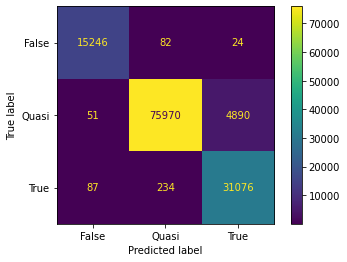

              precision    recall  f1-score   support

       False       0.99      0.99      0.99     15352
       Quasi       1.00      0.94      0.97     80911
        True       0.86      0.99      0.92     31397

    accuracy                           0.96    127660
   macro avg       0.95      0.97      0.96    127660
weighted avg       0.96      0.96      0.96    127660


Métricas de avaliação de teste:
[[ 3820    14     4]
 [    5 19018  1206]
 [   19    75  7755]]


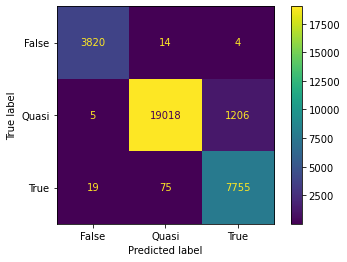

              precision    recall  f1-score   support

       False       0.99      1.00      0.99      3838
       Quasi       1.00      0.94      0.97     20229
        True       0.87      0.99      0.92      7849

    accuracy                           0.96     31916
   macro avg       0.95      0.97      0.96     31916
weighted avg       0.96      0.96      0.96     31916



In [25]:
# ============================================

print("\nMétricas de avaliação de treino:")

y_pred_train = grid_dt_random.predict(X_train)

print(confusion_matrix(y_train, y_pred_train))

ConfusionMatrixDisplay.from_predictions(y_train, y_pred_train)
plt.show()

print(classification_report(y_train, y_pred_train))

# ============================================

print("\nMétricas de avaliação de teste:")

y_pred_test = grid_dt_random.predict(X_test)

print(confusion_matrix(y_test, y_pred_test))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test)
plt.show()

print(classification_report(y_test, y_pred_test))

In [26]:
# ------------------------------------------
# CONCLUSAO : usando RandomSearch o modelo reduziu o overfit em comparacao
# as tentativas anteriores
# ------------------------------------------ 
print(grid_dt_random.best_estimator_["dt"].get_depth())
grid_dt_random.best_params_

8


{'dt__criterion': 'entropy',
 'dt__min_impurity_decrease': 0.0012062005956389177,
 'dt__splitter': 'best'}